# Data Collection
pulling reddit posts and wikipedia pageviews to study how AI discourse around wikipedia has evolved since chatgpt launched (nov 30, 2022).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.api_client import WikipediaAPIClient
from src.reddit_scraper import RedditScraper
from src.data_prep import clean_reddit_data, add_pre_post_chatgpt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs('../../data/raw/reddit_raw', exist_ok=True)
os.makedirs('../../data/processed/pageviews', exist_ok=True)
os.makedirs('../../reports/reddit_reports', exist_ok=True)

CHATGPT_LAUNCH = pd.Timestamp('2022-11-30')

## Reddit Scraping
covering 7 subreddits. each one gets a query tailored to what that community actually talks about (change: earlier it was catching random posts that happen to mention ai).

In [2]:
# each subreddit gets a query designed for that community
# r/wikipedia needs the most specific query because it's mostly trivia posts by default
SUBREDDIT_QUERIES = {
    'wikipedia':      'AI Wikipedia OR ChatGPT Wikipedia OR "AI-generated" Wikipedia OR "language model" Wikipedia OR LLM Wikipedia',
    'ChatGPT':        'Wikipedia',
    'artificial':     'Wikipedia',
    'MachineLearning':'Wikipedia',
    'OpenAI':         'Wikipedia',
    'technology':     'AI Wikipedia OR ChatGPT Wikipedia OR "artificial intelligence" Wikipedia',
    'singularity':    'Wikipedia'
}

In [3]:
scraper = RedditScraper()
reddit_raw = scraper.scrape_multiple_subreddits(SUBREDDIT_QUERIES, limit_per_sub=400)

print(f'\ntotal unique posts scraped: {len(reddit_raw)}')
print('\nby subreddit:')
print(reddit_raw['subreddit'].value_counts())


searching r/wikipedia...
  sort=relevance...
  scraped 231 posts from r/wikipedia (after 2020 filter)
  sort=new...
  scraped 164 posts from r/wikipedia (after 2020 filter)
  sort=top...
  scraped 164 posts from r/wikipedia (after 2020 filter)
  sort=comments...
  scraped 164 posts from r/wikipedia (after 2020 filter)
  deduplicated: 723 -> 233 unique posts

searching r/ChatGPT...
  sort=relevance...
  scraped 236 posts from r/ChatGPT (after 2020 filter)
  sort=new...
  scraped 238 posts from r/ChatGPT (after 2020 filter)
  sort=top...
  scraped 229 posts from r/ChatGPT (after 2020 filter)
  sort=comments...
  scraped 233 posts from r/ChatGPT (after 2020 filter)
  deduplicated: 936 -> 532 unique posts

searching r/artificial...
  sort=relevance...
  scraped 169 posts from r/artificial (after 2020 filter)
  sort=new...
  scraped 121 posts from r/artificial (after 2020 filter)
  sort=top...
  scraped 121 posts from r/artificial (after 2020 filter)
  sort=comments...
  scraped 121 posts 

In [4]:
reddit_df = clean_reddit_data(reddit_raw)
reddit_df = add_pre_post_chatgpt(reddit_df, date_col='date')

print(f'posts after cleaning: {len(reddit_df)}')
print(f'date range: {reddit_df["date"].min().strftime("%Y-%m-%d")} to {reddit_df["date"].max().strftime("%Y-%m-%d")}')
print(f'\npre-ChatGPT: {(reddit_df["period"] == "pre-ChatGPT").sum()} posts')
print(f'post-ChatGPT: {(reddit_df["period"] == "post-ChatGPT").sum()} posts')
print(f'\nnull text (title-only posts): {reddit_df["text"].isnull().sum()} ({reddit_df["text"].isnull().mean()*100:.1f}%)')

posts after cleaning: 1764
date range: 2020-01-02 to 2026-03-04

pre-ChatGPT: 305 posts
post-ChatGPT: 1459 posts

null text (title-only posts): 499 (28.3%)


## Wikipedia Pageviews
monthly pageviews from jan 2020 to present for the core AI-related articles. using the wikimedia REST api which gives clean per-article data going back to 2015.

In [5]:
# these are the articles most directly relevant to the ai/wikipedia story
AI_ARTICLES = [
    'Artificial_intelligence',
    'ChatGPT',
    'Large_language_model',
    'GPT-4',
    'OpenAI',
    'Wikipedia',
    'Generative_artificial_intelligence',
    'GPT-3'
]

client = WikipediaAPIClient()
pageviews_df = client.get_multiple_articles(AI_ARTICLES, start='20200101', end='20260301', granularity='monthly')

print(f'\npageview records fetched: {len(pageviews_df)}')
print(f'articles: {pageviews_df["article"].unique()}')
print(f'date range: {pageviews_df["timestamp"].min()} to {pageviews_df["timestamp"].max()}')

  fetching Artificial_intelligence...
  fetching ChatGPT...
  fetching Large_language_model...
  fetching GPT-4...
  fetching OpenAI...
  fetching Wikipedia...
  fetching Generative_artificial_intelligence...
  fetching GPT-3...

pageview records fetched: 450
articles: ['Artificial_intelligence' 'ChatGPT' 'Large_language_model' 'GPT-4'
 'OpenAI' 'Wikipedia' 'Generative_artificial_intelligence' 'GPT-3']
date range: 2020-01-01 00:00:00 to 2026-03-01 00:00:00


## Save Raw Data

In [6]:
reddit_df.to_csv('../../data/raw/reddit_raw/reddit_ai_wikipedia_posts.csv', index=False)
print(f'saved {len(reddit_df)} reddit posts')

pageviews_df.to_csv('../../data/processed/pageviews/ai_article_pageviews.csv', index=False)
print(f'saved {len(pageviews_df)} pageview records')

saved 1764 reddit posts
saved 450 pageview records


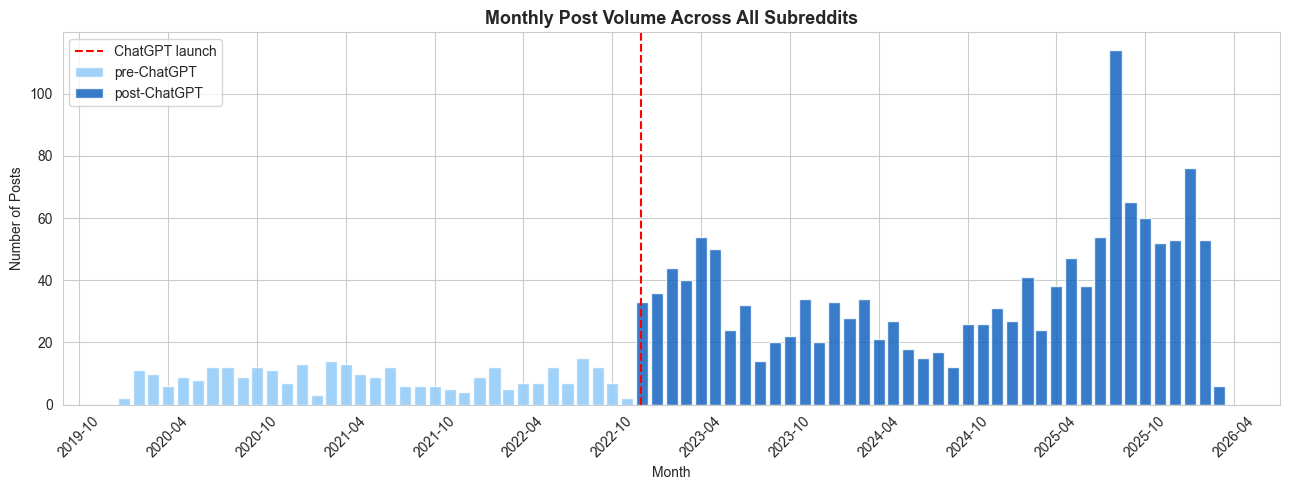

In [7]:
# monthly post volume over time, colored by period
reddit_df['month'] = reddit_df['date'].dt.to_period('M').dt.to_timestamp()
monthly_counts = reddit_df.groupby(['month', 'period']).size().reset_index(name='post_count')

fig, ax = plt.subplots()

for period, color in [('pre-ChatGPT', '#90CAF9'), ('post-ChatGPT', '#1565C0')]:
    subset = monthly_counts[monthly_counts['period'] == period]
    ax.bar(subset['month'], subset['post_count'], width=25, color=color, label=period, alpha=0.85)

ax.axvline(CHATGPT_LAUNCH, color='red', linestyle='--', linewidth=1.5, label='ChatGPT launch')
ax.set_title('Monthly Post Volume Across All Subreddits', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Posts')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/monthly_post_volume.png', dpi=150, bbox_inches='tight')
plt.show()

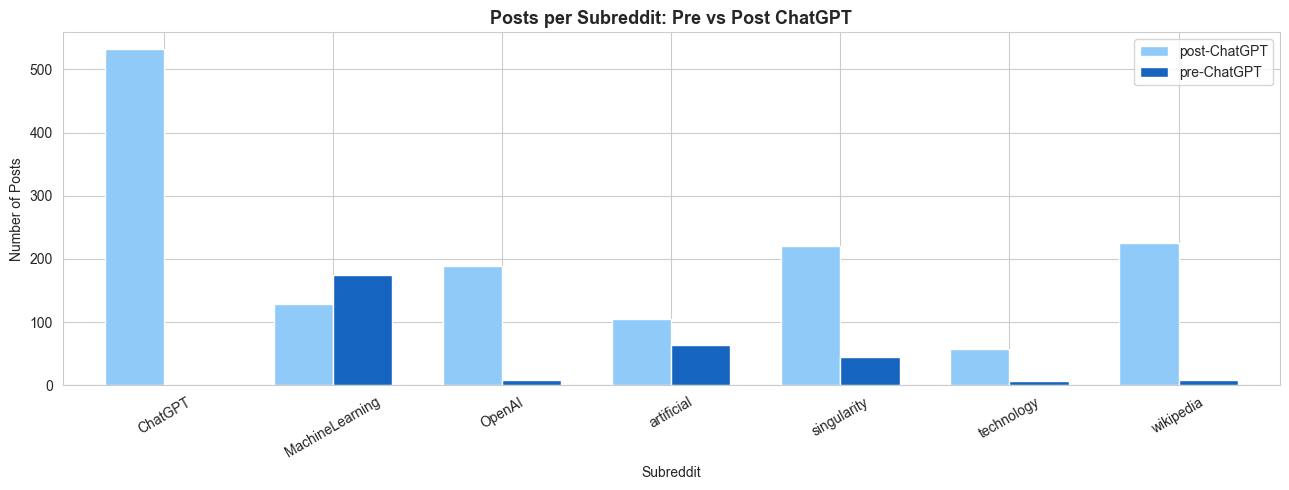

In [8]:
# post count per subreddit with pre/post breakdown
sub_period = reddit_df.groupby(['subreddit', 'period']).size().unstack(fill_value=0)

fig, ax = plt.subplots()
sub_period.plot(kind='bar', ax=ax, color=['#90CAF9', '#1565C0'], edgecolor='white', width=0.7)
ax.set_title('Posts per Subreddit: Pre vs Post ChatGPT', fontsize=13, fontweight='bold')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Number of Posts')
ax.legend(title='')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/subreddit_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

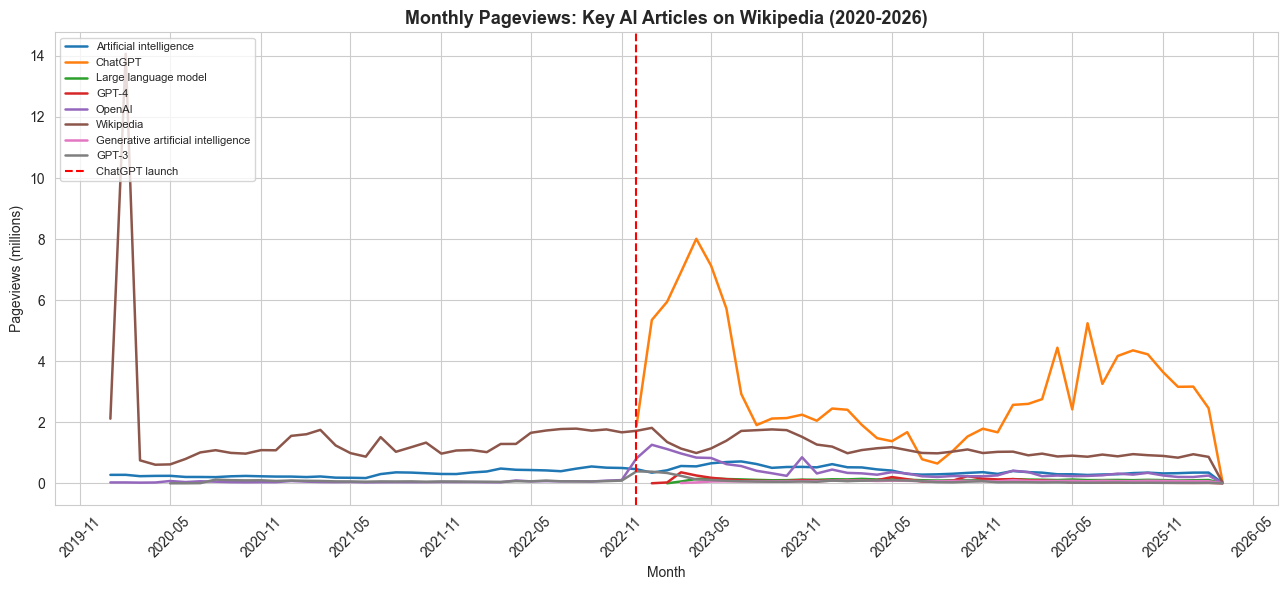

In [9]:
# wikipedia pageviews for key AI articles over time
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette('tab10', n_colors=len(AI_ARTICLES))

for i, article in enumerate(AI_ARTICLES):
    subset = pageviews_df[pageviews_df['article'] == article]
    if subset.empty:
        continue
    ax.plot(subset['timestamp'], subset['views'] / 1e6, label=article.replace('_', ' '), color=palette[i], linewidth=1.8)

ax.axvline(CHATGPT_LAUNCH, color='red', linestyle='--', linewidth=1.5, label='ChatGPT launch')
ax.set_title('Monthly Pageviews: Key AI Articles on Wikipedia (2020-2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Pageviews (millions)')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/article_pageviews.png', dpi=150, bbox_inches='tight')
plt.show()

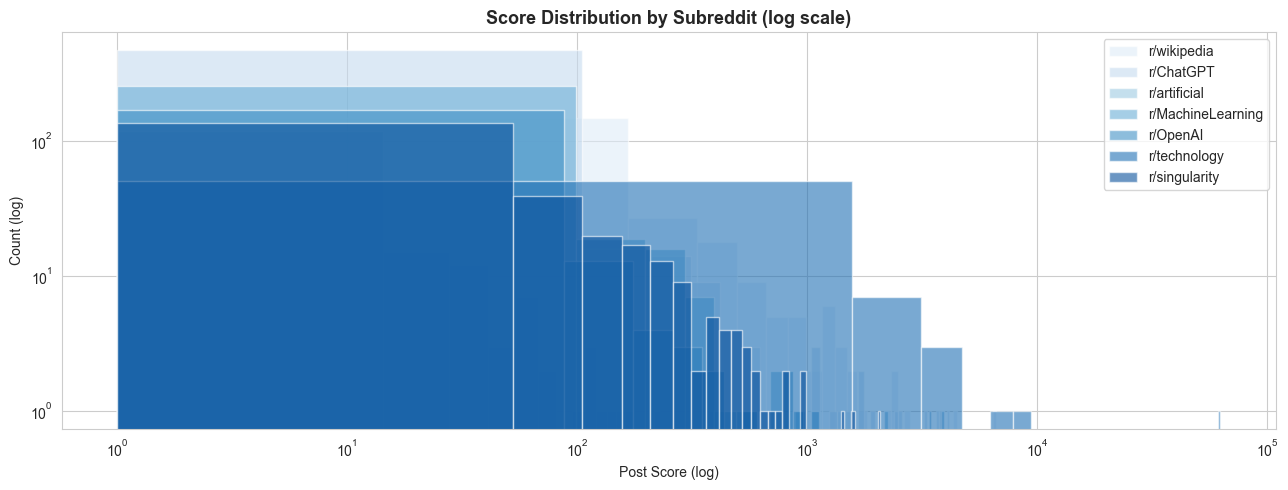


score summary (median is more useful than mean given outliers):
                 median    mean    max  count
subreddit                                    
ChatGPT             3.0   102.3   4152    532
MachineLearning     9.0    72.6   3916    304
OpenAI              4.0    69.8   3471    197
artificial          4.0    26.6    536    169
singularity        50.0   139.3   2074    265
technology         78.0  1826.6  62607     64
wikipedia          38.0   300.4   6607    233


In [10]:
# score distribution by subreddit on log scale (skew is extreme so log makes this readable)
fig, ax = plt.subplots()

subreddits = reddit_df['subreddit'].unique()
palette = sns.color_palette('Blues', n_colors=len(subreddits))

for i, sub in enumerate(subreddits):
    scores = reddit_df[reddit_df['subreddit'] == sub]['score'].clip(lower=1)
    ax.hist(scores, bins=40, alpha=0.6, label=f'r/{sub}', color=palette[i], log=True)

ax.set_xscale('log')
ax.set_title('Score Distribution by Subreddit (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('Post Score (log)')
ax.set_ylabel('Count (log)')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# summary table
print('\nscore summary (median is more useful than mean given outliers):')
print(reddit_df.groupby('subreddit')['score'].agg(['median', 'mean', 'max', 'count']).round(1).to_string())

In [11]:
# final data summary
print('=== dataset summary ===')
print(f'total reddit posts: {len(reddit_df)}')
print(f'subreddits covered: {reddit_df["subreddit"].nunique()}')
print(f'date range: {reddit_df["date"].min().strftime("%Y-%m-%d")} to {reddit_df["date"].max().strftime("%Y-%m-%d")}')
print(f'pre-ChatGPT: {(reddit_df["period"]=="pre-ChatGPT").sum()} posts')
print(f'post-ChatGPT: {(reddit_df["period"]=="post-ChatGPT").sum()} posts')
print(f'\ntotal pageview records: {len(pageviews_df)}')
print(f'articles tracked: {pageviews_df["article"].nunique()}')

=== dataset summary ===
total reddit posts: 1764
subreddits covered: 7
date range: 2020-01-02 to 2026-03-04
pre-ChatGPT: 305 posts
post-ChatGPT: 1459 posts

total pageview records: 450
articles tracked: 8
